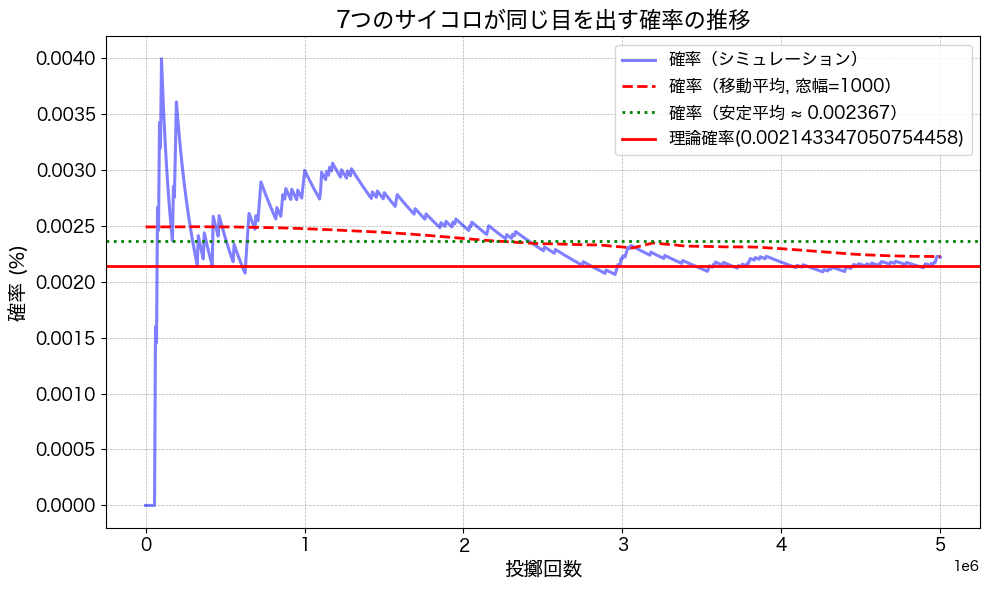

Raw values at target throw counts:
Throw count = 100: Raw Value = 0.000000000
Throw count = 500: Raw Value = 0.000000000
Throw count = 1000: Raw Value = 0.000000000
Throw count = 5000: Raw Value = 0.000000000
Throw count = 10000: Raw Value = 0.000000000
Throw count = 50000: Raw Value = 0.000000000
Throw count = 100000: Raw Value = 0.004000000
Throw count = 500000: Raw Value = 0.002400000
Throw count = 1000000: Raw Value = 0.003000000
Throw count = 5000000: Raw Value = 0.002220000
Throw count = 7000000: Raw Value = nan
Throw count = 9000000: Raw Value = nan
0.002143347050754458


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

# === Config ===
FILENAME = 'dice.txt'
ROLL_WINDOW = 1000
STABLE_SPAN = 1000
LABEL_NAME = "確率"  # Probability

plt.rcParams['font.family'] = 'Hiragino Sans'

# === Load Data ===
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip()

# Theoretical probability for all 2 dice same face
theoretical_prob = 1 / (6 ** 6) * 100  # This seems off for 7 dice, maybe 1/6^7?


x = df['throw_count'].values
y = df['percentage'].values

# Sort data by x (throw_count)
sorted_indices = np.argsort(x)
x_sorted = x[sorted_indices]
y_sorted = y[sorted_indices]

# Smooth x for spline interpolation
s = 800
x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), s)

# Spline smoothing
from scipy.interpolate import make_interp_spline
spline = make_interp_spline(x_sorted, y_sorted, k=3)
y_smooth = spline(x_smooth)

# Rolling mean smoothing
rolling = uniform_filter1d(y_smooth, size=ROLL_WINDOW)

# Stable average of last STABLE_SPAN points
final_span = min(STABLE_SPAN, len(y_smooth))
stable_avg = np.mean(y_smooth[-final_span:]) if final_span >= 5 else None

# === Plotting ===
plt.figure(figsize=(10, 6))

# Main smooth line (blue, thick, semi-transparent)
plt.plot(x_smooth, y_smooth, color='blue', linewidth=2.2, alpha=0.5, label=LABEL_NAME + "（シミュレーション）")

# Rolling mean (red dashed, thick, opaque)
plt.plot(x_smooth, rolling, color='red', linestyle='--', linewidth=2, alpha=1.0,
         label=f"{LABEL_NAME}（移動平均, 窓幅={ROLL_WINDOW}）")

# Stable average line (green dotted)
if stable_avg is not None:
    plt.axhline(stable_avg, color='green', linestyle=':', linewidth=2, alpha=1.0,
                label=f"{LABEL_NAME}（安定平均 ≈ {stable_avg:.6f}）")

# Theoretical probability (red dashed, thickness like your original)
plt.axhline(y=theoretical_prob, color='red', linestyle='-', linewidth=2,
            label=f"理論確率({theoretical_prob})")

# Labels in Japanese with bigger font
plt.xlabel('投擲回数', fontsize=14)
plt.ylabel('確率 (%)', fontsize=14)
plt.title('7つのサイコロが同じ目を出す確率の推移', fontsize=16)

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

target_counts = [
    100,
    500,
    1_000,
    5_000,
    10_000,
    50_000,
    100_000,
    500_000,
    1_000_000,
    5_000_000,
]

raw_values_at_targets = {}

for count in target_counts:
    # Find the row where 'throw_count' == count
    row = df[df['throw_count'] == count]
    if not row.empty:
        raw_value = row['percentage'].values[0]
    else:
        raw_value = np.nan
    raw_values_at_targets[count] = raw_value

# === Print results ===
print("Raw values at target throw counts:")
for count, val in raw_values_at_targets.items():
    print(f"Throw count = {count}: Raw Value = {val:.9f}")
print(theoretical_prob)


In [53]:
import pandas as pd
import re

FILENAMES = [
    "dice_2_5000000.txt",
    "dice_4_5000000.txt",
    "dice_6_5000000.txt",
    "dice_8_5000000.txt",
    "dice_10_5000000.txt",
]

for filename in FILENAMES:
    # Extract number of dice from filename
    match = re.search(r'dice_(\d+)_', filename)
    if not match:
        print(f"Could not parse dice count from filename: {filename}")
        continue

    dice_count = int(match.group(1))
    expected = (1 / 6**(dice_count - 1)) * 100  # all dice same face = 1/6^(n-1), since first die is "free"

    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip()

    actual = df['percentage'].iloc[-1]

    deviation = ((actual - expected) / expected) * 100

    print(f"{filename}:")
    print(f"  Dice Count = {dice_count}")
    print(f"  Expected   = {expected:.9f}%")
    print(f"  Actual     = {actual:.9f}%")
    print(f"  Deviation  = {deviation:+.5f}%\n")


dice_2_5000000.txt:
  Dice Count = 2
  Expected   = 16.666666667%
  Actual     = 16.667500000%
  Deviation  = +0.00500%

dice_4_5000000.txt:
  Dice Count = 4
  Expected   = 0.462962963%
  Actual     = 0.462260000%
  Deviation  = -0.15184%

dice_6_5000000.txt:
  Dice Count = 6
  Expected   = 0.012860082%
  Actual     = 0.012360000%
  Deviation  = -3.88864%

dice_8_5000000.txt:
  Dice Count = 8
  Expected   = 0.000357225%
  Actual     = 0.000580000%
  Deviation  = +62.36288%

dice_10_5000000.txt:
  Dice Count = 10
  Expected   = 0.000009923%
  Actual     = 0.000500000%
  Deviation  = +4938.84800%



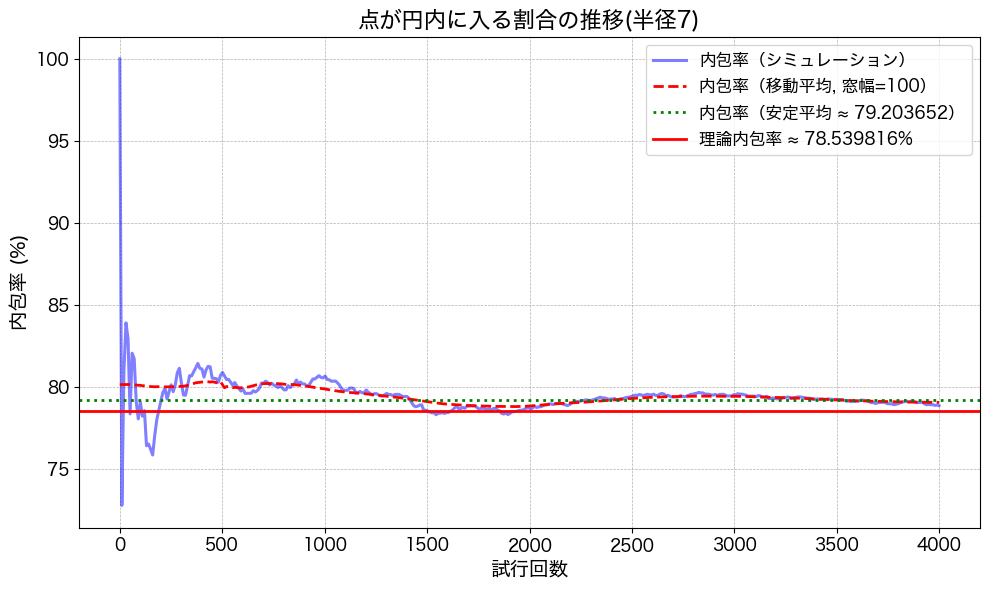

=== 各繰り返し回数での内包率と理論値との差 ===
500 回: 内包率 = 80.800000% | 理論値 = 78.539816% | 偏差 = +2.8778%
700 回: 内包率 = 80.142857% | 理論値 = 78.539816% | 偏差 = +2.0411%
1000 回: 内包率 = 80.600000% | 理論値 = 78.539816% | 偏差 = +2.6231%
2000 回: 内包率 = 78.650000% | 理論値 = 78.539816% | 偏差 = +0.1403%
3000 回: 内包率 = 79.500000% | 理論値 = 78.539816% | 偏差 = +1.2225%
4000 回: 内包率 = 78.850000% | 理論値 = 78.539816% | 偏差 = +0.3949%


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
from scipy.ndimage import uniform_filter1d

# === Config ===
FILENAME = 'area.txt'
ROLL_WINDOW = 100
STABLE_SPAN = 100
LABEL_NAME = "内包率"  # Percentage Within
plt.rcParams['font.family'] = 'Hiragino Sans'

# === 理論内包率の計算 ===
square_area = 14 * 14
circle_radius = 7
circle_area = np.pi * (circle_radius ** 2)
theoretical_prob = (circle_area / square_area) * 100  # 理論内包率

# === Load Data ===
cols = ['index', 'radius', 'x', 'y', 'withinCount', 'percentageWithin', 'theoretical']
df = pd.read_csv(FILENAME, skiprows=1, names=cols)
df.columns = df.columns.str.strip()

x = df['index'].values
y = df['percentageWithin'].values

# Sort data
sorted_indices = np.argsort(x)
x_sorted = x[sorted_indices]
y_sorted = y[sorted_indices]

# Smooth x for spline interpolation
s = 400
x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), s)

# Spline smoothing
spline = make_interp_spline(x_sorted, y_sorted, k=3)
y_smooth = spline(x_smooth)

# Rolling mean smoothing
rolling = uniform_filter1d(y_smooth, size=ROLL_WINDOW)

# Stable average of last STABLE_SPAN points
final_span = min(STABLE_SPAN, len(y_smooth))
stable_avg = np.mean(y_smooth[-final_span:]) if final_span >= 5 else None

# === Plotting ===
plt.figure(figsize=(10, 6))

# Main smooth line (blue)
plt.plot(x_smooth, y_smooth, color='blue', linewidth=2.2, alpha=0.5,
         label=LABEL_NAME + "（シミュレーション）")

# Rolling mean (red dashed)
plt.plot(x_smooth, rolling, color='red', linestyle='--', linewidth=2,
         label=f"{LABEL_NAME}（移動平均, 窓幅={ROLL_WINDOW}）")

# Stable average line (green dotted)
if stable_avg is not None:
    plt.axhline(y=stable_avg, color='green', linestyle=':', linewidth=2,
                label=f"{LABEL_NAME}（安定平均 ≈ {stable_avg:.6f}）")

# Theoretical line (red solid)
plt.axhline(y=theoretical_prob, color='red', linestyle='-', linewidth=2,
            label=f"理論内包率 ≈ {theoretical_prob:.6f}%")

# Labels
plt.xlabel('試行回数', fontsize=14)
plt.ylabel(f'{LABEL_NAME} (%)', fontsize=14)
plt.title('点が円内に入る割合の推移(半径7)', fontsize=16)

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

TARGET_COUNTS = [
    500,
    700,
    1000,
    2000,
    3000,
    4000
]

# === 理論内包率の計算 ===
square_area = 14 * 14
circle_radius = 7
circle_area = np.pi * (circle_radius ** 2)
expected_percentage = (circle_area / square_area) * 100
print("=== 各繰り返し回数での内包率と理論値との差 ===")
for count in TARGET_COUNTS:
    if count-1 > len(df):
        print(f"{count-1} 回: データが存在しません")
        continue
    percentage = df.loc[df['index'] == count-1, 'percentageWithin']
    if not percentage.empty:
        actual = percentage.values[0]
        deviation = ((actual - expected_percentage) / expected_percentage) * 100
        print(f"{count} 回: 内包率 = {actual:.6f}% | 理論値 = {expected_percentage:.6f}% | 偏差 = {deviation:+.4f}%")
    else:
        print(f"{count} 回: データが見つかりません")

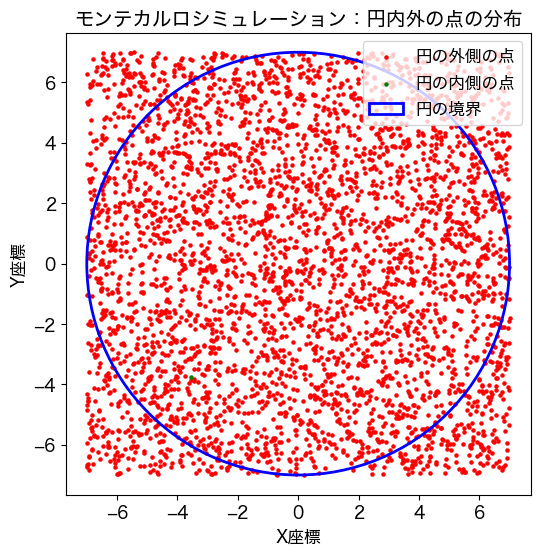

NameError: name 'x_smooth' is not defined

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Hiragino Sans'
# Load CSV data: columns = index,radius,x,y,withinCount,percentageWithin,theoretical
filename = "area.txt"

x_in, y_in = [], []
x_out, y_out = [], []

with open(filename, 'r') as f:
    next(f)  # ヘッダー行をスキップ
    for line in f:
        parts = line.strip().split(',')
        if len(parts) < 7:
            continue

        x = float(parts[2])
        y = float(parts[3])
        is_within = int(parts[4])

        if is_within == 1:
            x_in.append(x)
            y_in.append(y)
        else:
            x_out.append(x)
            y_out.append(y)

# プロット設定
plt.figure(figsize=(6,6))
plt.scatter(x_out, y_out, color='red', s=5, label='円の外側の点')
plt.scatter(x_in, y_in, color='green', s=5, label='円の内側の点')

# 円の境界線を描画
radius = max(max(abs(x) for x in x_in + x_out), max(abs(y) for y in y_in + y_out))
circle = plt.Circle((0, 0), radius, color='blue', fill=False, linewidth=2, label='円の境界')
plt.gca().add_artist(circle)

plt.axis('equal')
plt.legend(fontsize=12)
plt.title('モンテカルロシミュレーション：円内外の点の分布', fontsize=14)
plt.xlabel('X座標', fontsize=12)
plt.ylabel('Y座標', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

# 以下、x_smooth と rolling は事前に定義済みの配列であることが前提です

target_counts = [100, 1000, 10000, 100000]
rolling_at_targets = {}

for count in target_counts:
    # 目標回数に最も近いインデックスを取得
    idx = np.abs(x_smooth - count).argmin()
    rolling_at_targets[count] = rolling[idx]

# ローリング平均の値を出力
print("特定の試行回数での移動平均値:")
for count, value in rolling_at_targets.items():
    print(f"試行回数 {count}: 移動平均 ≈ {value:.6f}")


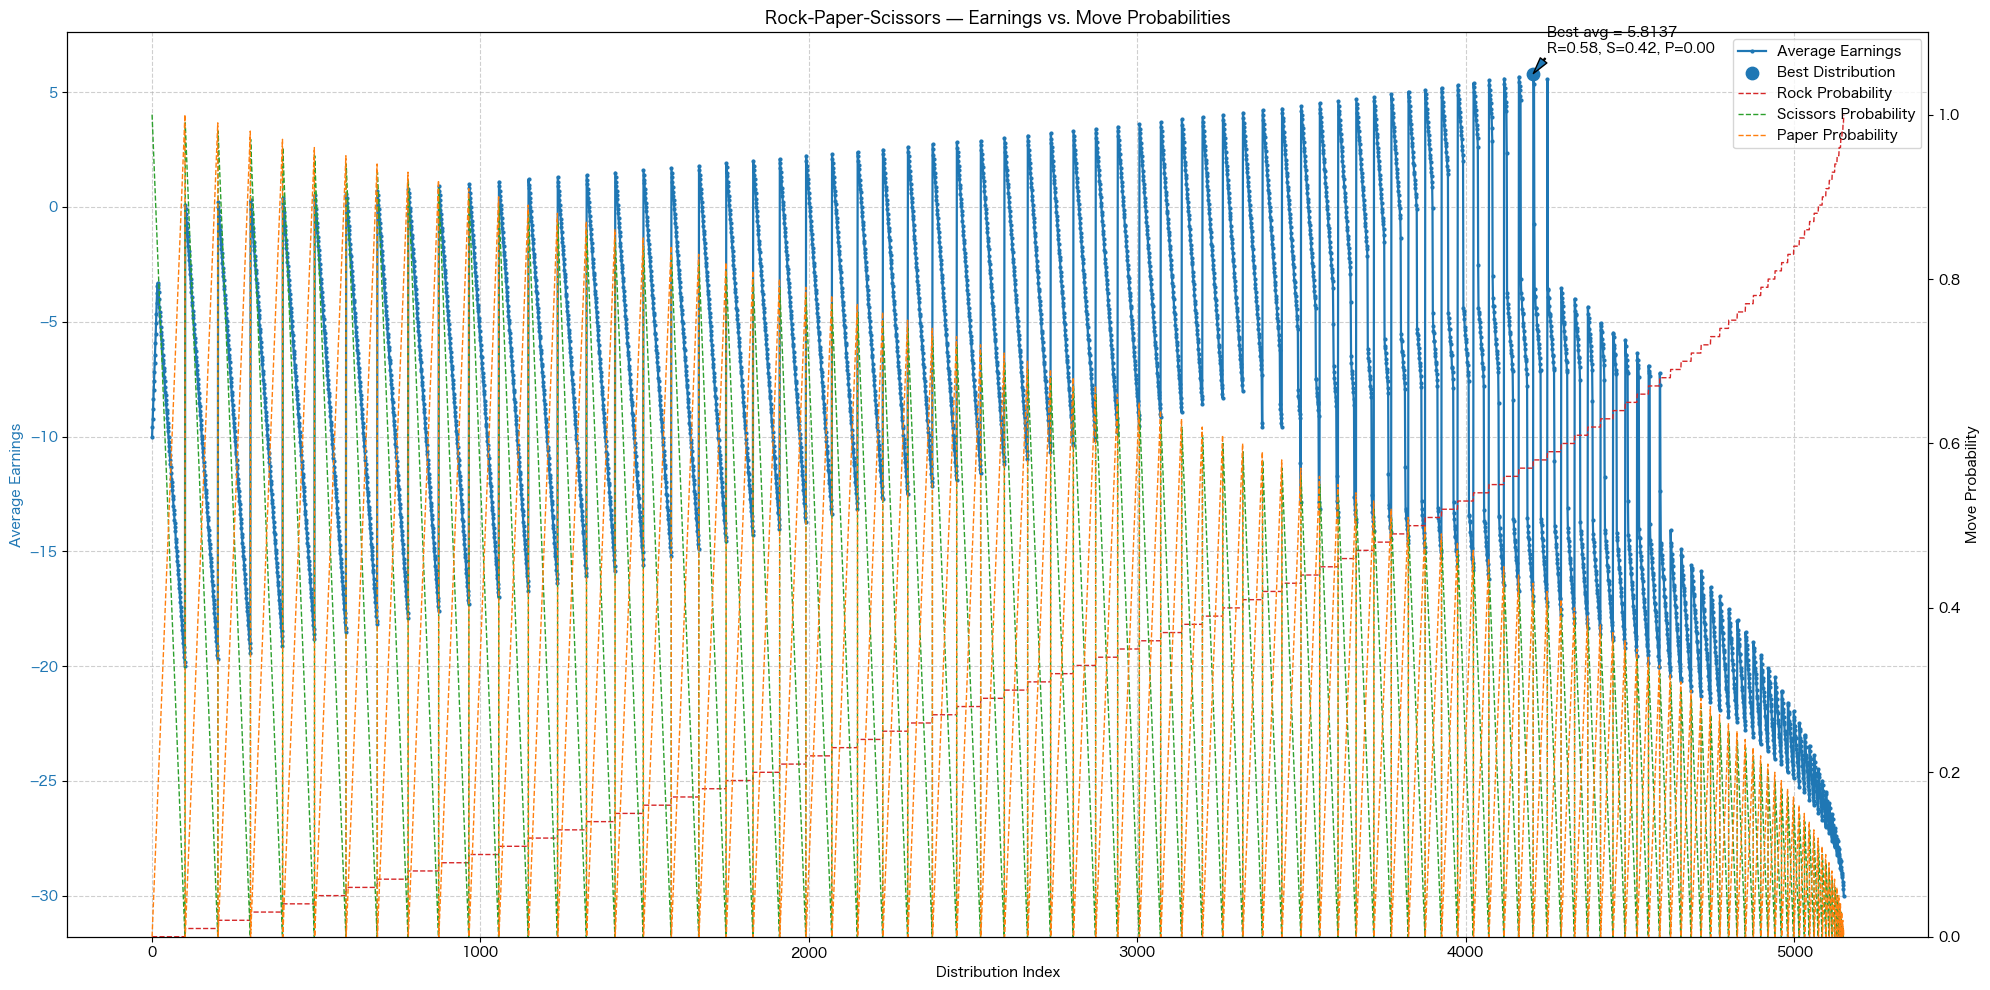

=== 各繰り返し回数での内包率と理論値との差 ===


KeyError: 'index'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("janken-ai.txt")

best_row = df.loc[df['average_earnings'].idxmax()]

fig, ax1 = plt.subplots(figsize=(20, 10))

# ── left axis: average earnings ────────────────────────────────────
ax1.plot(df['distribution_index'], df['average_earnings'],
         marker='o', markersize=2, linewidth=1.6,
         color='tab:blue', label='Average Earnings')
ax1.set_xlabel('Distribution Index')
ax1.set_ylabel('Average Earnings', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# ── right axis: probabilities, scaled 0‒1 over full height ────────
ax2 = ax1.twinx()
ax2.plot(df['distribution_index'], df['rock_prob'],
         linestyle='--', linewidth=1.0, color='tab:red',
         label='Rock Probability')
ax2.plot(df['distribution_index'], df['scissors_prob'],
         linestyle='--', linewidth=1.0, color='tab:green',
         label='Scissors Probability')
ax2.plot(df['distribution_index'], df['paper_prob'],
         linestyle='--', linewidth=1.0, color='tab:orange',
         label='Paper Probability')
ax2.set_ylabel('Move Probability', color='black')
ax2.set_ylim(0, 1.1)                   # full height for 0‒1
ax2.tick_params(axis='y')

# ── highlight best distribution (optional) ────────────────────────
ax1.scatter(best_row['distribution_index'], best_row['average_earnings'],
            s=80, zorder=1, label='Best Distribution')
ax1.annotate(
    f"Best avg = {best_row['average_earnings']:.4f}\n"
    f"R={best_row['rock_prob']:.2f}, "
    f"S={best_row['scissors_prob']:.2f}, "
    f"P={best_row['paper_prob']:.2f}",
    xy=(best_row['distribution_index'], best_row['average_earnings']),
    xytext=(10, 15), textcoords="offset points",
    arrowprops=dict(width=0.8, headwidth=6)
)

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Rock‑Paper‑Scissors — Earnings vs. Move Probabilities')
ax1.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()




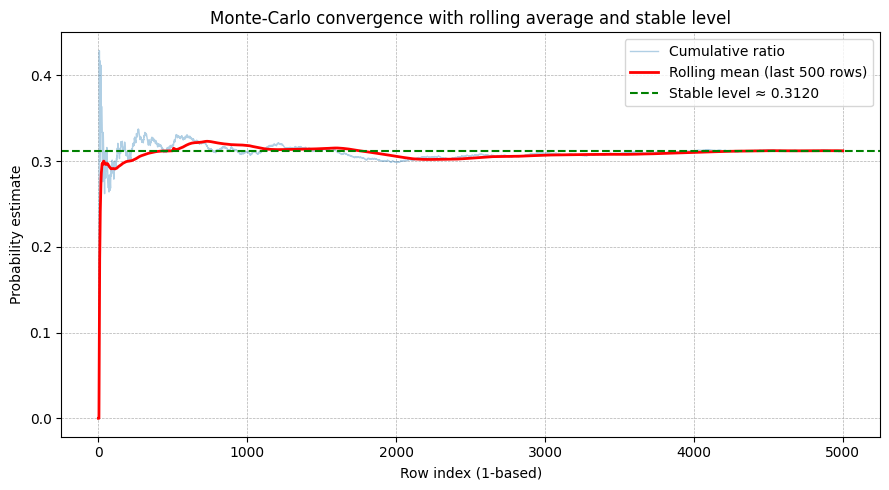

In [20]:
import csv
import matplotlib.pyplot as plt
from collections import deque

# ---------------- CONFIG ----------------
FILENAME      = "height.txt"   # adjust path if needed
ROLL_WINDOW   = 500             # rolling mean window size
STABLE_SPAN   = 1000             # how many last rows to average for a "stable" level
# ----------------------------------------

trials, ratio, rolling = [], [], []
q = deque()
acc = 0.0

with open(FILENAME, newline="") as f:
    reader = csv.reader(f)
    next(reader, None)  # skip header
    for idx, row in enumerate(reader, start=1):
        if len(row) < 3:
            continue
        r = float(row[2])
        trials.append(idx)
        ratio.append(r)

        # Rolling mean
        q.append(r); acc += r
        if len(q) > ROLL_WINDOW:
            acc -= q.popleft()
        rolling.append(acc / len(q))

# --- Stable horizontal line: mean of last STABLE_SPAN ratios
tail = ratio[-STABLE_SPAN:] if len(ratio) >= STABLE_SPAN else ratio
stable_level = sum(tail) / len(tail) if tail else 0.0

# --- Plot -------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(trials, ratio,  lw=1, alpha=0.35, label="Cumulative ratio")
plt.plot(trials, rolling, lw=2, color="red",
         label=f"Rolling mean (last {ROLL_WINDOW} rows)")

# Horizontal stable level
plt.axhline(stable_level, color="green", linestyle="--",
            label=f"Stable level ≈ {stable_level:.4f}")

plt.xlabel("Row index (1‑based)")
plt.ylabel("Probability estimate")
plt.title("Monte‑Carlo convergence with rolling average and stable level")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


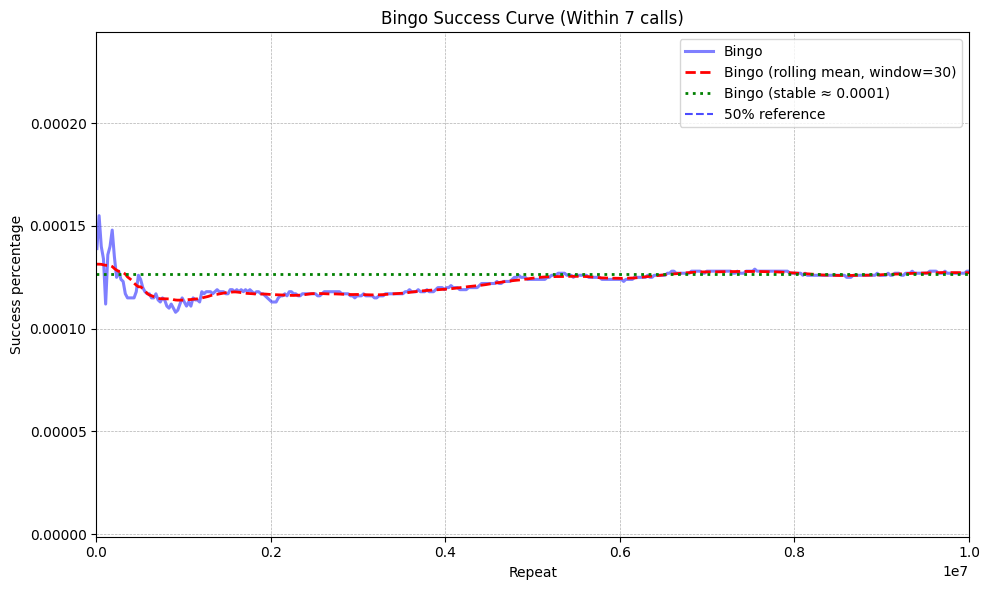

In [3]:
#!/usr/bin/env python3
"""
Plot Bingo simulation results from a CSV file.
Uses smooth line graphs with interpolation, rolling average, and stable level.
Only shows successful Bingo results (percentage > 0).
"""
import csv
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
from scipy.ndimage import uniform_filter1d

# ---------------- CONFIG ----------------
FILENAME = "bingo-1.txt"
ROLL_WINDOW = 30     # smoothing window on interpolated data
STABLE_SPAN = 50     # how many last points to average
# ----------------------------------------

success_x, success_y = [], []

with open(FILENAME, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            repeat = int(row["repeat"])
            pct = float(row["percentage"])
            if pct > 0:
                success_x.append(repeat)
                success_y.append(pct)
        except (ValueError, KeyError):
            continue

# ── choose y-axis limits ──────────────────────────────────────────────────────
if success_y:
    ymax = max(success_y)
else:
    ymax = 0.0
margin = 0.005 * (1 if ymax == 0 else ymax)
ylow = -margin
yhigh = ymax + margin

# ── plot interpolated data ─────────────────────────────────────────────────────
def sorted_spline(x, y, color, label, s=400):
    if len(x) < 4:
        plt.plot(x, y, color=color, linestyle='-', marker='o', label=f"{label} (raw)")
        return

    x_np, y_np = np.array(x), np.array(y)
    sorted_idx = np.argsort(x_np)
    x_sorted, y_sorted = x_np[sorted_idx], y_np[sorted_idx]

    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), s)
    spline = make_interp_spline(x_sorted, y_sorted, k=3)
    y_smooth = spline(x_smooth)
    
    # ── Main smooth curve ──────────────────────────────────────────
    plt.plot(x_smooth, y_smooth, color=color, linewidth=2.2, alpha=0.5, label=label)

    # ── Rolling mean ───────────────────────────────────────────────
    rolling = uniform_filter1d(y_smooth, size=ROLL_WINDOW)
    plt.plot(x_smooth, rolling, color="red", linestyle='--', linewidth=2, alpha=1.0,
             label=f"{label} (rolling mean, window={ROLL_WINDOW})")

    # ── Stable final average ───────────────────────────────────────
    final_span = min(STABLE_SPAN, len(y_smooth))
    if final_span >= 5:
        stable_avg = np.mean(y_smooth[-final_span:])
        plt.axhline(stable_avg, color="green", linestyle=":", linewidth=2, alpha=1.0,
                    label=f"{label} (stable ≈ {stable_avg:.4f})")


# ── Plot setup ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

if success_x:
    sorted_spline(success_x, success_y, color="blue", label="Bingo")

plt.axhline(0.5, color="blue", linestyle="--", linewidth=1.5, alpha=0.7, label="50% reference")

plt.title("Bingo Success Curve (Within 7 calls)")
plt.xlabel("Repeat")
plt.ylabel("Success percentage")
plt.xlim(0, max(success_x, default=10) + 1)
plt.ylim(ylow, yhigh)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


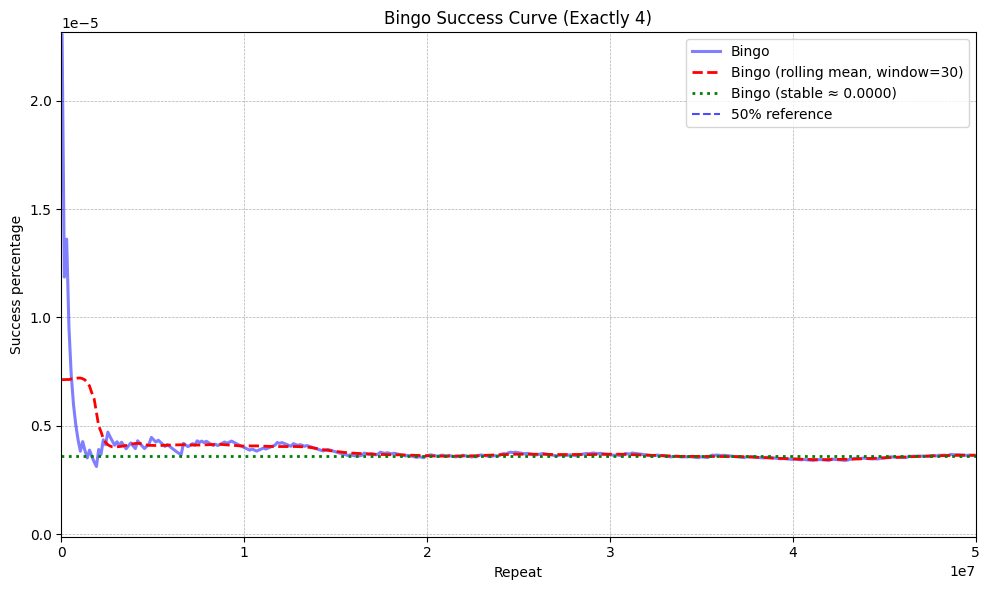

In [20]:
#!/usr/bin/env python3
"""
Plot Bingo simulation results from a CSV file.
Uses smooth line graphs with interpolation, rolling average, and stable level.
Only shows successful Bingo results (percentage > 0).
"""
import csv
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
from scipy.ndimage import uniform_filter1d

# ---------------- CONFIG ----------------
FILENAME = "bingo-2.txt"
ROLL_WINDOW = 30     # smoothing window on interpolated data
STABLE_SPAN = 50     # how many last points to average
# ----------------------------------------

success_x, success_y = [], []

with open(FILENAME, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            repeat = int(row["repeat"])
            pct = float(row["percentage"])
            if pct > 0:
                success_x.append(repeat)
                success_y.append(pct)
        except (ValueError, KeyError):
            continue

# ── choose y-axis limits ──────────────────────────────────────────────────────
if success_y:
    ymax = max(success_y)
else:
    ymax = 0.0
margin = 0.005 * (1 if ymax == 0 else ymax)
ylow = -margin
yhigh = ymax + margin

# ── plot interpolated data ─────────────────────────────────────────────────────
def sorted_spline(x, y, color, label, s=400):
    if len(x) < 4:
        plt.plot(x, y, color=color, linestyle='-', marker='o', label=f"{label} (raw)")
        return

    x_np, y_np = np.array(x), np.array(y)
    sorted_idx = np.argsort(x_np)
    x_sorted, y_sorted = x_np[sorted_idx], y_np[sorted_idx]

    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), s)
    spline = make_interp_spline(x_sorted, y_sorted, k=3)
    y_smooth = spline(x_smooth)
    
    # ── Main smooth curve ──────────────────────────────────────────
    plt.plot(x_smooth, y_smooth, color=color, linewidth=2.2, alpha=0.5, label=label)

    # ── Rolling mean ───────────────────────────────────────────────
    rolling = uniform_filter1d(y_smooth, size=ROLL_WINDOW)
    plt.plot(x_smooth, rolling, color="red", linestyle='--', linewidth=2, alpha=1.0,
             label=f"{label} (rolling mean, window={ROLL_WINDOW})")

    # ── Stable final average ───────────────────────────────────────
    final_span = min(STABLE_SPAN, len(y_smooth))
    if final_span >= 5:
        stable_avg = np.mean(y_smooth[-final_span:])
        plt.axhline(stable_avg, color="green", linestyle=":", linewidth=2, alpha=1.0,
                    label=f"{label} (stable ≈ {stable_avg:.4f})")


# ── Plot setup ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

if success_x:
    sorted_spline(success_x, success_y, color="blue", label="Bingo")

plt.axhline(0.5, color="blue", linestyle="--", linewidth=1.5, alpha=0.7, label="50% reference")

plt.title("Bingo Success Curve (Exactly 4)")
plt.xlabel("Repeat")
plt.ylabel("Success percentage")
plt.xlim(0, max(success_x, default=10) + 1)
plt.ylim(ylow, yhigh)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


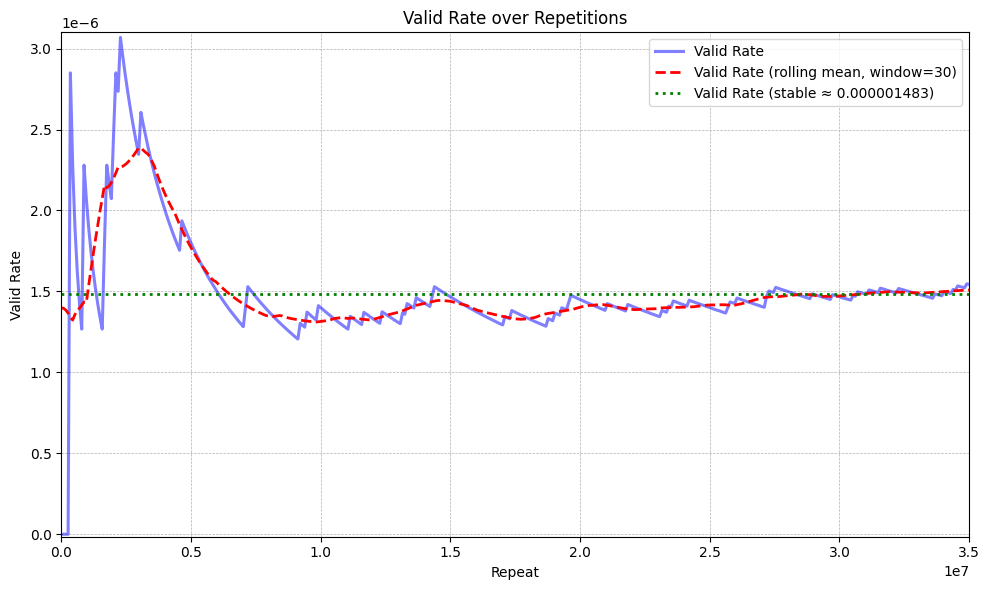

In [13]:
#!/usr/bin/env python3
"""
Plot Valid Rate simulation results from a CSV file.
Includes interpolation, rolling average smoothing, and final stable average.
"""

import csv
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline
from scipy.ndimage import uniform_filter1d

# === CONFIG ===
FILENAME = "bingo-3.txt"
ROLL_WINDOW = 30
STABLE_SPAN = 100
LABEL_NAME = "Valid Rate"
Y_COLUMN = "valid_rate"

# === Load Data ===
x_vals, y_vals = [], []

with open(FILENAME, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            x = int(row["repeat"])
            y = float(row[Y_COLUMN])
            x_vals.append(x)
            y_vals.append(y)
        except (ValueError, KeyError):
            continue

# === Determine Y-axis range ===
ymax = max(y_vals) if y_vals else 0.0
margin = 0.005 * (1 if ymax == 0 else ymax)
ylow = -margin
yhigh = ymax + margin

# === Plotting Function ===
def sorted_spline(x, y, color, label, s=400):
    if len(x) < 4:
        plt.plot(x, y, color=color, linestyle='-', marker='o', label=f"{label} (raw)")
        return

    x_np = np.array(x)
    y_np = np.array(y)
    sorted_idx = np.argsort(x_np)
    x_sorted = x_np[sorted_idx]
    y_sorted = y_np[sorted_idx]

    x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), s)
    spline = make_interp_spline(x_sorted, y_sorted, k=3)
    y_smooth = spline(x_smooth)

    # Main smooth line
    plt.plot(x_smooth, y_smooth, color=color, linewidth=2.2, alpha=0.5, label=label)

    # Rolling mean using uniform_filter1d
    rolling = uniform_filter1d(y_smooth, size=ROLL_WINDOW)
    plt.plot(x_smooth, rolling, color="red", linestyle='--', linewidth=2, alpha=1.0,
             label=f"{label} (rolling mean, window={ROLL_WINDOW})")

    # Final stable average line
    final_span = min(STABLE_SPAN, len(y_smooth))
    if final_span >= 5:
        stable_avg = np.mean(y_smooth[-final_span:])
        plt.axhline(stable_avg, color="green", linestyle=":", linewidth=2, alpha=1.0,
                    label=f"{label} (stable ≈ {stable_avg:.9f})")

# === Final Plot ===
plt.figure(figsize=(10, 6))

if x_vals:
    sorted_spline(x_vals, y_vals, color="blue", label=LABEL_NAME)

plt.title("Valid Rate over Repetitions")
plt.xlabel("Repeat")
plt.ylabel("Valid Rate")
plt.xlim(0, max(x_vals, default=10) + 1)
plt.ylim(ylow, yhigh)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


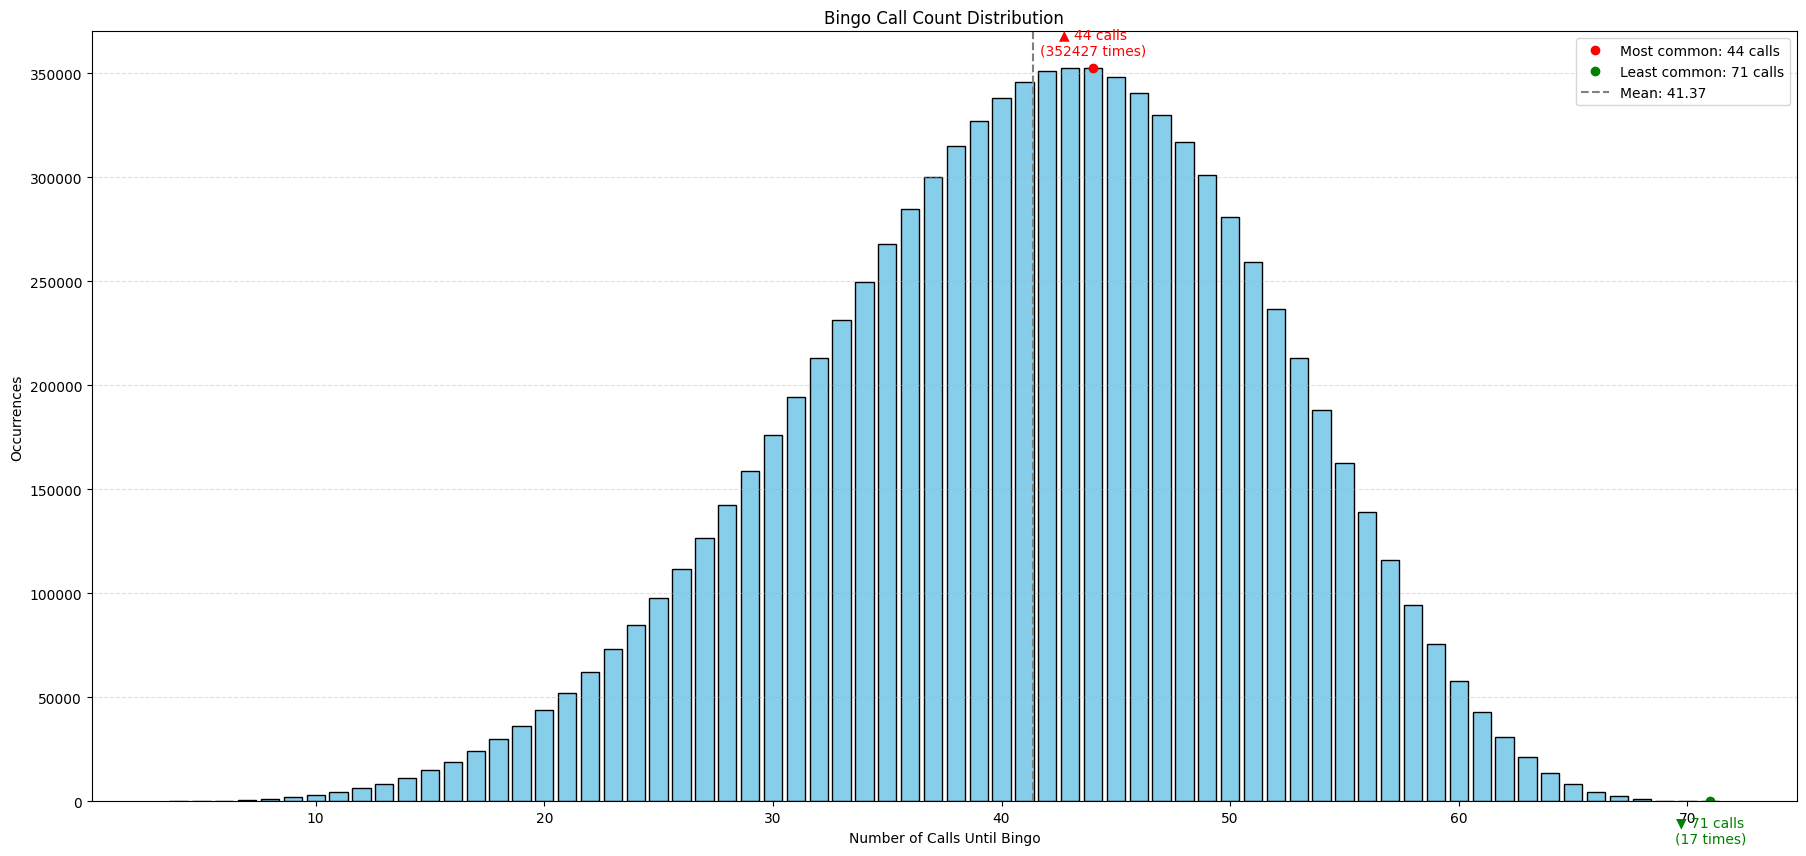

In [ ]:
#!/usr/bin/env python3
"""
Plot Bingo call count distribution from a CSV file.
Highlights which number of calls appears most and least frequently.
"""

import csv
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
FILENAME = "call_distribution.csv"
TITLE = "Bingo Call Count Distribution"
# ----------------------------------------

call_counts = []
occurrences = []

# Read CSV data
with open(FILENAME, newline="") as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        try:
            count = int(row["call_count"])
            freq = int(row["occurrences"])
            if freq > 0:  # Ignore zero occurrences
                call_counts.append(count)
                occurrences.append(freq)
        except (KeyError, ValueError):
            continue

# Identify most and least frequent
if not occurrences:
    raise ValueError("No valid data found in CSV.")

max_freq = max(occurrences)
min_freq = min(occurrences)

# Indices where max/min occur
max_idx = occurrences.index(max_freq)
min_idx = occurrences.index(min_freq)

most_common_call = call_counts[max_idx]
least_common_call = call_counts[min_idx]

# Plot
plt.figure(figsize=(22, 10))
plt.bar(call_counts, occurrences, color='skyblue', edgecolor='black')

# Highlight most and least common calls
plt.plot(most_common_call, max_freq, 'ro', label=f"Most common: {most_common_call} calls")
plt.annotate(f"▲ {most_common_call} calls\n({max_freq} times)",
             (most_common_call, max_freq),
             textcoords="offset points", xytext=(0, 10), ha='center', color='red', )

plt.plot(least_common_call, min_freq, 'go', label=f"Least common: {least_common_call} calls")
plt.annotate(f"▼ {least_common_call} calls\n({min_freq} times)",
             (least_common_call, min_freq),
             textcoords="offset points", xytext=(0, -30), ha='center', color='green')

# Optional: vertical mean line
total_simulations = sum(occurrences)
weighted_sum = sum(c * f for c, f in zip(call_counts, occurrences))
mean_calls = weighted_sum / total_simulations
plt.axvline(mean_calls, color='gray', linestyle='--', linewidth=1.5,
            label=f"Mean: {mean_calls:.2f}")

# Labels and styling
plt.title(TITLE)
plt.xlabel("Number of Calls Until Bingo")
plt.ylabel("Occurrences")
plt.grid(True, linestyle="--", alpha=0.4, axis='y')
plt.legend()
plt.show()


In [1]:
import itertools

# Define individuals in order of height (tallest to shortest)
# M1 > W1 > M2 > W2 > M3 > W3 > M4 > W4 > M5 > W5
people = ['M1', 'W1', 'M2', 'W2', 'M3', 'W3', 'M4', 'W4', 'M5', 'W5']

# Map each person to their height rank (higher number = shorter)
height_rank = {p: i for i, p in enumerate(people)}

def is_valid(permutation):
    for i, person in enumerate(permutation):
        if person.startswith('W'):
            w_height = height_rank[person]
            left = permutation[:i]
            found_taller_man = any(p.startswith('M') and height_rank[p] < w_height for p in left)
            if not found_taller_man:
                return False
    return True

# Enumerate all permutations
valid_count = 0
total_count = 0

for perm in itertools.permutations(people):
    total_count += 1
    if is_valid(perm):
        valid_count += 1

probability = valid_count / total_count
valid_count, total_count, probability


(893025, 3628800, 0.24609375)

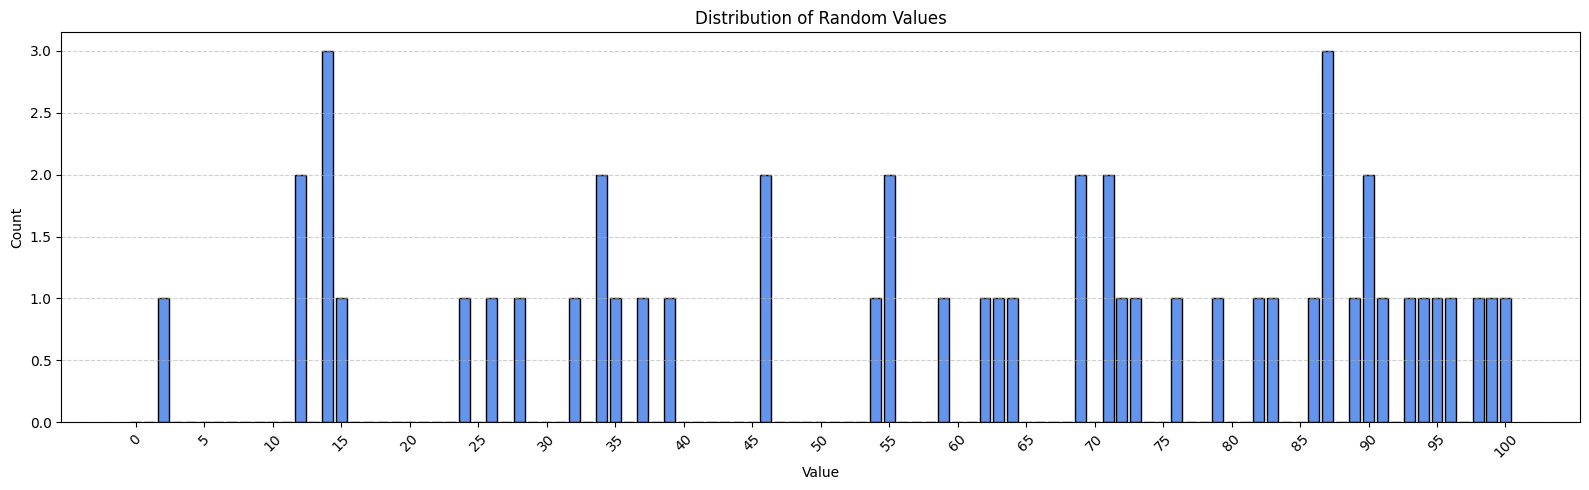

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("rand_general.csv")  # Replace with actual path if needed

# Plot settings
plt.figure(figsize=(16, 5))  # Wider figure for 100 bars
bars = plt.bar(df['value'], df['count'], color='cornflowerblue', edgecolor='black')

# X-axis ticks (show every 5th to reduce clutter)
plt.xticks(df['value'][::5], rotation=45)

# Labels and Title
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Distribution of Random Values')

# Gridlines for clarity
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Tight layout to avoid clipping
plt.tight_layout()
plt.show()


カイ二乗統計量: 103.030000000
P値: 0.370758315
✅ 有意な偏りは検出されませんでした（p >= 0.05）


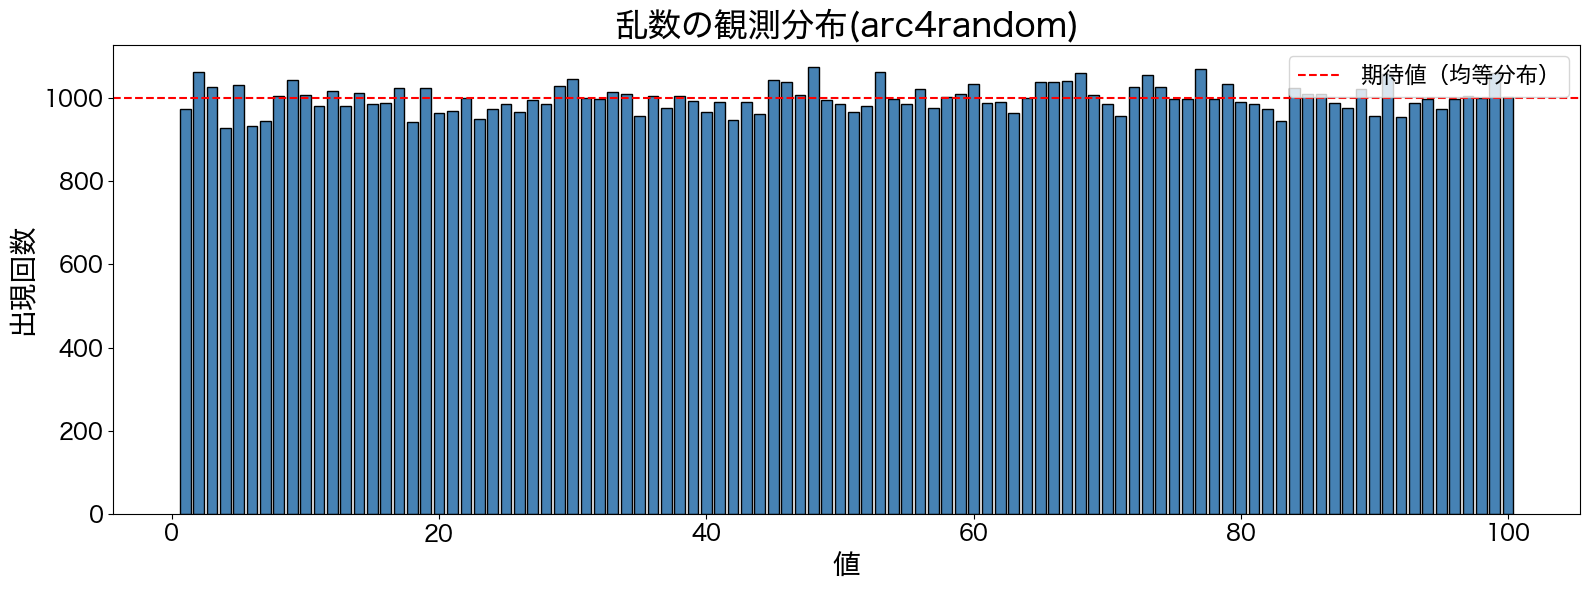

In [8]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# フォント設定（日本語対応）
plt.rcParams['font.family'] = 'Hiragino Sans'

# データ読み込み
df = pd.read_csv("rand_general.csv")  # ファイル名を適宜変更してください

# 観測値カウント抽出
observed = df['count'].values
n = len(observed)
total = observed.sum()

# 一様分布の期待値
expected = [total / n] * n

# カイ二乗検定
chi2_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f"カイ二乗統計量: {chi2_stat:.9f}")
print(f"P値: {p_value:.9f}")

# 判定
if p_value < 0.05:
    print("❌ 統計的に有意な偏りが検出されました（p < 0.05）")
else:
    print("✅ 有意な偏りは検出されませんでした（p >= 0.05）")

# 可視化（任意）
plt.figure(figsize=(16, 6))
plt.bar(df['value'], observed, color='steelblue', edgecolor='black')

# ラベルやタイトルのフォントサイズを大きくする
plt.axhline(y=total / n, color='red', linestyle='--', label='期待値（均等分布）')
plt.title('乱数の観測分布(arc4random)', fontsize=24)
plt.xlabel('値', fontsize=20)
plt.ylabel('出現回数', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()


カイ二乗統計量: 83.980000000
P値: 0.859645089
✅ 有意な偏りは検出されませんでした（p >= 0.05）


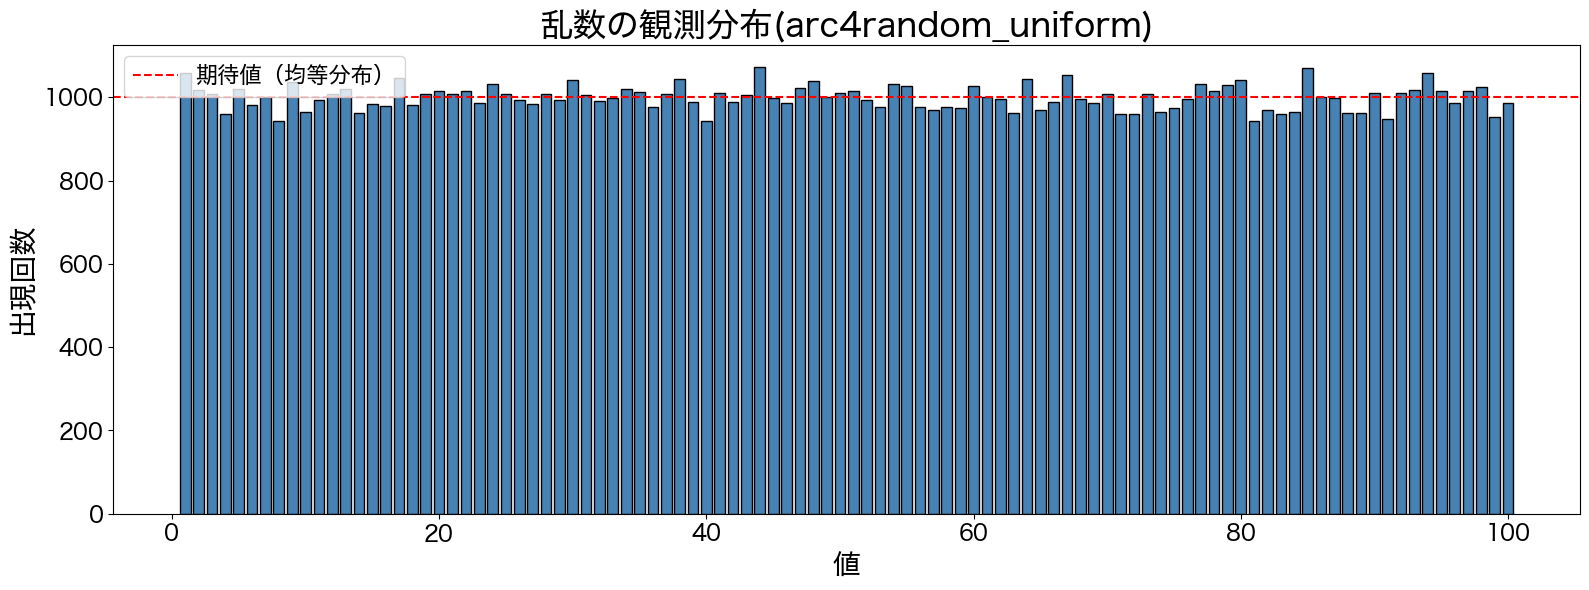

In [7]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# フォント設定（日本語対応）
plt.rcParams['font.family'] = 'Hiragino Sans'

# データ読み込み
df = pd.read_csv("rand_uniform.csv")  # ファイル名を適宜変更してください

# 観測値カウント抽出
observed = df['count'].values
n = len(observed)
total = observed.sum()

# 一様分布の期待値
expected = [total / n] * n

# カイ二乗検定
chi2_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f"カイ二乗統計量: {chi2_stat:.9f}")
print(f"P値: {p_value:.9f}")

# 判定
if p_value < 0.05:
    print("❌ 統計的に有意な偏りが検出されました（p < 0.05）")
else:
    print("✅ 有意な偏りは検出されませんでした（p >= 0.05）")

# 可視化（任意）
plt.figure(figsize=(16, 6))
plt.bar(df['value'], observed, color='steelblue', edgecolor='black')

# ラベルやタイトルのフォントサイズを大きくする
plt.axhline(y=total / n, color='red', linestyle='--', label='期待値（均等分布）')
plt.title('乱数の観測分布(arc4random_uniform)', fontsize=24)
plt.xlabel('値', fontsize=20)
plt.ylabel('出現回数', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()


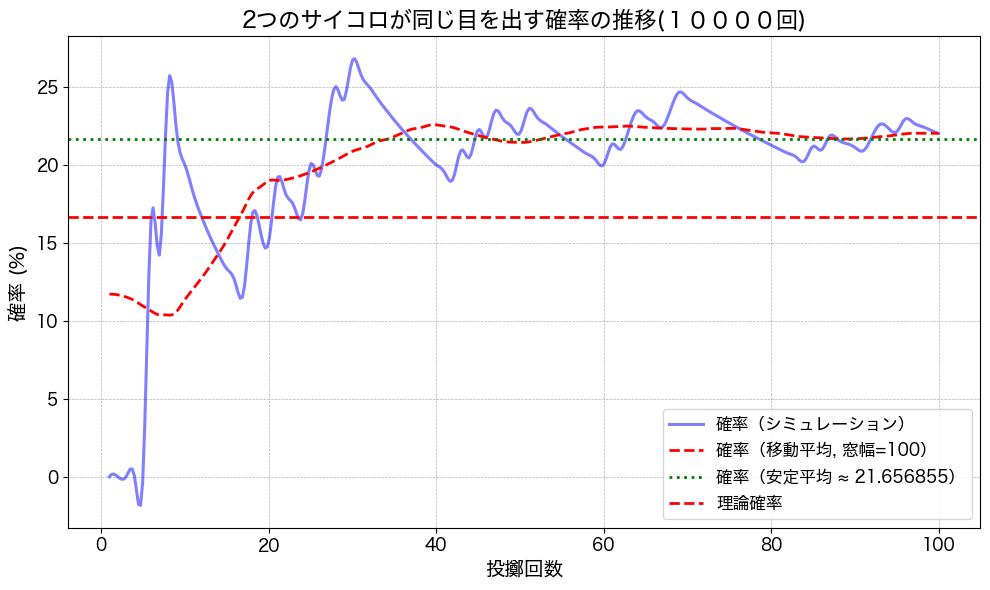

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

# === Config ===
FILENAME = 'dice_2.txt'
ROLL_WINDOW = 100
STABLE_SPAN = 100
LABEL_NAME = "確率"  # Probability

plt.rcParams['font.family'] = 'Hiragino Sans'

# === Load Data ===
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip()

# Theoretical probability for all 2 dice same face
theoretical_prob = 1 / (6 ** 1) * 100  # This seems off for 7 dice, maybe 1/6^7?

x = df['throw_count'].values
y = df['percentage'].values

# Sort data by x (throw_count)
sorted_indices = np.argsort(x)
x_sorted = x[sorted_indices]
y_sorted = y[sorted_indices]

# Smooth x for spline interpolation
s = 400
x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), s)

# Spline smoothing
from scipy.interpolate import make_interp_spline
spline = make_interp_spline(x_sorted, y_sorted, k=3)
y_smooth = spline(x_smooth)

# Rolling mean smoothing
rolling = uniform_filter1d(y_smooth, size=ROLL_WINDOW)

# Stable average of last STABLE_SPAN points
final_span = min(STABLE_SPAN, len(y_smooth))
stable_avg = np.mean(y_smooth[-final_span:]) if final_span >= 5 else None

# === Plotting ===
plt.figure(figsize=(10, 6))

# Main smooth line (blue, thick, semi-transparent)
plt.plot(x_smooth, y_smooth, color='blue', linewidth=2.2, alpha=0.5, label=LABEL_NAME + "（シミュレーション）")

# Rolling mean (red dashed, thick, opaque)
plt.plot(x_smooth, rolling, color='red', linestyle='--', linewidth=2, alpha=1.0,
         label=f"{LABEL_NAME}（移動平均, 窓幅={ROLL_WINDOW}）")

# Stable average line (green dotted)
if stable_avg is not None:
    plt.axhline(stable_avg, color='green', linestyle=':', linewidth=2, alpha=1.0,
                label=f"{LABEL_NAME}（安定平均 ≈ {stable_avg:.6f}）")

# Theoretical probability (red dashed, thickness like your original)
plt.axhline(y=theoretical_prob, color='red', linestyle='--', linewidth=2,
            label="理論確率")

# Labels in Japanese with bigger font
plt.xlabel('投擲回数', fontsize=14)
plt.ylabel('確率 (%)', fontsize=14)
plt.title('2つのサイコロが同じ目を出す確率の推移(１００００回)', fontsize=16)

plt.legend(fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()
